# **Feature Engineering**

## Objectives

- Engineer features for regression modeling (SalePrice)
- Encode categorical variables, transform numeric features if necessary
- Reduce variables using correlation-based selection
- Generate a clean dataset ready for model training

## Inputs
* Cleaned dataset: 
    - `outputs/datasets/cleaned/CleanedData.csv`

## Outputs
- Transformed TrainSet and TestSet with engineered features
- List of transformers applied:
    - Ordinal categorical encoding
    - Log/Power/Box-Cox transformations (if successful)
    - Smart correlation selection


### Import Cell

In [ ]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from feature_engine.encoding import OrdinalEncoder
from feature_engine.outliers import Winsorizer

sns.set(style="whitegrid")

---

## Change working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [45]:
import os
current_dir = os.getcwd()
print("Current directory:", current_dir)

Current directory: c:\


We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [46]:
# Move to parent directory
os.chdir(os.path.dirname(current_dir))
print("New current directory:", os.getcwd())

New current directory: c:\


Confirm the new current directory

In [47]:
current_dir = os.getcwd()
current_dir

'c:\\'

# Load Cleaned Data 

In [48]:
import pandas as pd

data_path = r"C:\Users\david\Portfolio 5\heritage-housing\outputs\datasets\cleaned\CleanedData.csv"
TrainSet = pd.read_csv(data_path)
TrainSet.head(3)

,1stFlrSF,2ndFlrSF,BedroomAbvGr,BsmtExposure,BsmtFinSF1,BsmtFinType1,BsmtUnfSF,GarageArea,GarageFinish,GarageYrBlt,...,LotArea,LotFrontage,MasVnrArea,OpenPorchSF,OverallCond,OverallQual,TotalBsmtSF,YearBuilt,YearRemodAdd,SalePrice
0,856,854.0,3.0,No,706,GLQ,150,548,RFn,2003.0,...,8450,65.0,196.0,61,5,7,856,2003,2003,208500
1,1262,0.0,3.0,Gd,978,ALQ,284,460,RFn,1976.0,...,9600,80.0,0.0,0,8,6,1262,1976,1976,181500
2,920,866.0,3.0,Mn,486,GLQ,434,608,RFn,2001.0,...,11250,68.0,162.0,42,5,7,920,2001,2002,223500


---

## Helper Functions

In [ ]:
def check_missing_values(df):
    missing = df.isna().sum()
    missing = missing[missing > 0]
    if missing.empty:
        print("* No missing values found.")
    else:
        print("* Missing values found:")
        print(missing)


def diagnostic_plots(df, col):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    sns.histplot(df[col], kde=True, ax=axes[0])
    stats.probplot(df[col], dist="norm", plot=axes[1])
    sns.boxplot(x=df[col], ax=axes[2])

    axes[0].set_title("Histogram")
    axes[1].set_title("QQ Plot")
    axes[2].set_title("Boxplot")

    fig.suptitle(col, fontsize=18, y=1.05)
    plt.tight_layout()
    plt.show()

## Identity Variables for Feature Engineering

### Ordinal Categorical Variables

- `KitchenQual`, `ExterQual`, `ExterCond`, `BsmtQual`, `BsmtCond`, `GarageQual`, `GarageCond`, `FireplaceQu`  
These features have a natural order, so we will encode them numerically.

### Numeric Variables for Transformation:**  
- `GrLivArea`, `LotArea`, `TotalBsmtSF`, `1stFlrSF`, `BsmtFinSF1`  
These features are right-skewed or have outliers and could potentially benefit from log/power/Box-Cox transformations.

### Variables for Correlation-Based Reduction:**  
- All numeric features  
To reduce multicollinearity and  thus keep only the most informative features.

---

## Apply Feature Engineering Transformers

### Ordinal Categorical Encoding 
Change text labels to numeric

In [ ]:
ordinal_vars = ['KitchenQual', 'BsmtExposure', 'BsmtFinType1', 'GarageFinish']

print("Missing values before encoding:")
check_missing_values(TrainSet[ordinal_vars])

encoder = OrdinalEncoder(
    encoding_method='arbitrary',
    variables=ordinal_vars,
    missing_values='ignore'
)

TrainSet = encoder.fit_transform(TrainSet)

print("* Ordinal categorical encoding done!")
TrainSet[ordinal_vars].head()

* Ordinal categorical encoding done!


c:\Users\david\Portfolio 5\heritage-housing\venv\Lib\site-packages\feature_engine\encoding\base_encoder.py:260: UserWarning: During the encoding, NaN values were introduced in the feature(s) BsmtExposure, BsmtFinType1, GarageFinish.
  warnings.warn(


### Numerical Transformations 
- Reduce skewness for numeric features that strongly influence `SalePrice`
- Apply multiple log transformations to the most important features identified in the EDA Analysis.
    - These features are likely to benefit the most from a log transformation due to being right skewed: `GrLivArea`, `LotArea`, `TotalBsmtSF`, `1stFlrSF`, `BsmtFinSF1` 

#### Create Diagnostic Plots and Generate Log Transformed Features 

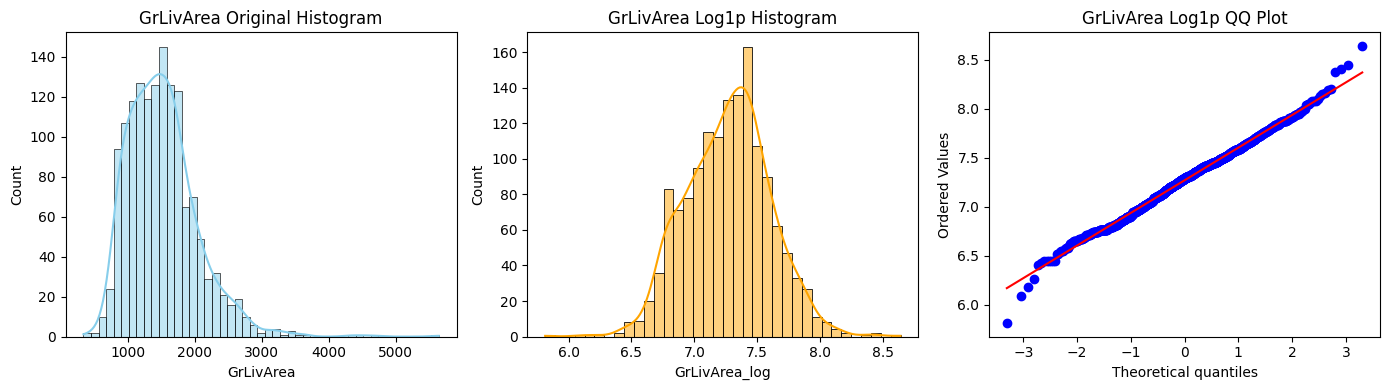

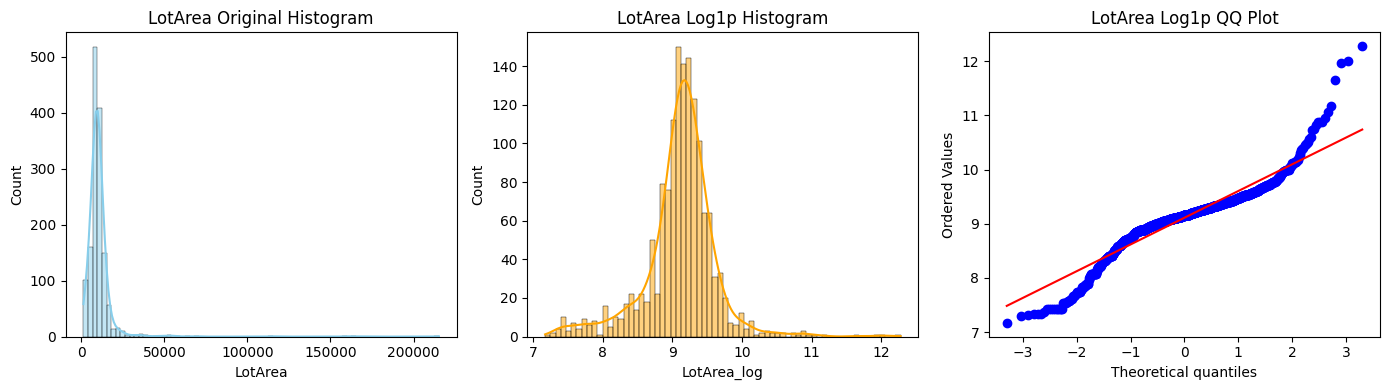

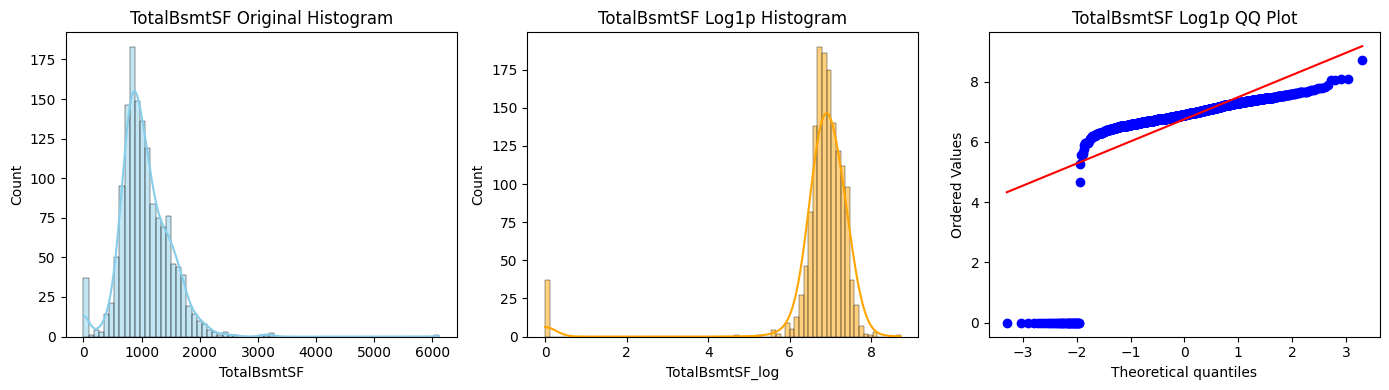

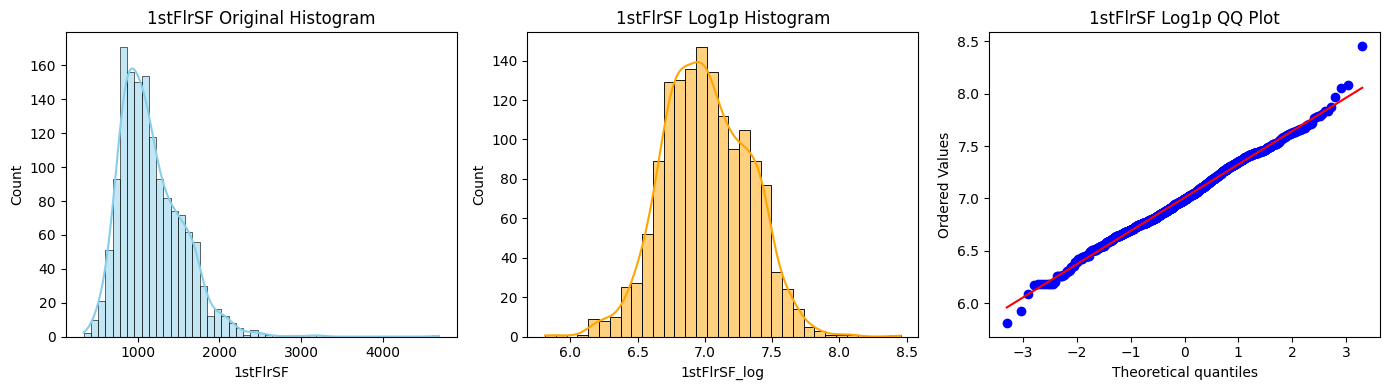

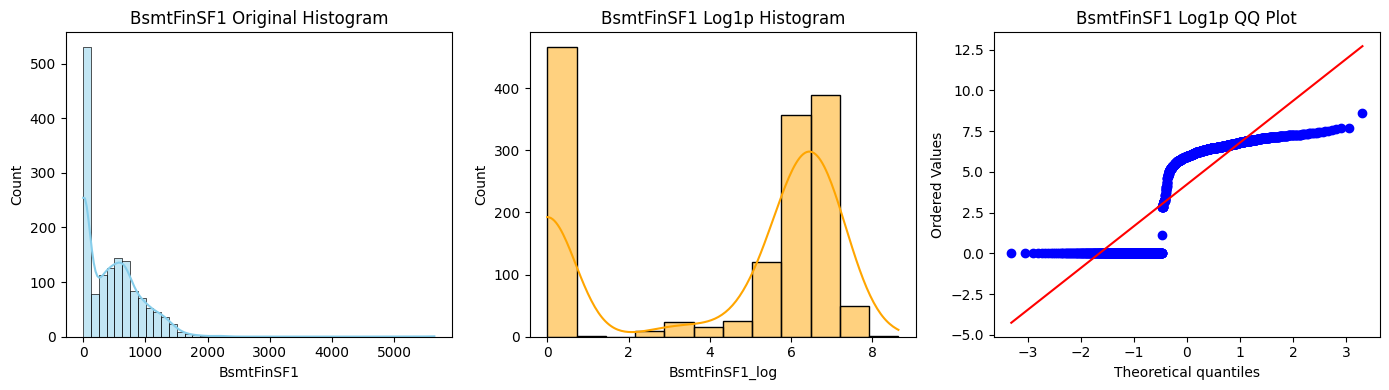

In [ ]:
# skewed numeric features to transform
numeric_skewed = ['GrLivArea', 'LotArea', 'TotalBsmtSF', '1stFlrSF', 'BsmtFinSF1']

df_engineering = TrainSet[numeric_skewed].copy()

print("Missing values check for numeric skewed variables:")
check_missing_values(df_engineering)

for col in numeric_skewed:
    df_engineering[col + "_log"] = np.log1p(df_engineering[col])

    print(f"\nVariable: {col}")
    diagnostic_plots(df_engineering, col)
    diagnostic_plots(df_engineering, col + "_log")

#### Transformation Summary Table
| Feature        | Original Distribution                 | After Log1p Transformation              | QQ Plot Improvement? | Final Summary |
|---------------|----------------------------------------|------------------------------------------|----------------------|--------------|
| **BsmtFinSF1** | Very right-skewed, many zeros          | Skew reduced but still clustered         | Slight improvement   | Better, but still not normal due to many 0 values |
| **TotalBsmtSF** | Right-skewed with low/zero values    | More compressed and less skewed          | Moderate improvement | Improved, but still not perfectly normal |
| **1stFlrSF**   | Already close to normal               | Slight compression, little change        | Small improvement    | Log not necessary but acceptable |
| **GrLivArea**  | Mild/moderate right skew              | More symmetric distribution              | Good improvement     | Log transformation is useful here |
| **LotArea**    | Strong right skew, many outliers      | Major skew reduction                     | Good improvement     | Log transform helped a lot, but outliers remain |

### Apply Selected Transformations to Train Set

In [ ]:
for col in numeric_skewed:
    TrainSet[col + "_log"] = np.log1p(TrainSet[col])

print("* Log transformations applied to TrainSet")

### Outlier Handling (Winsorization)

In [53]:
# Select numeric variables (exclude target 'SalePrice')
numeric_vars = TrainSet.select_dtypes(include=['int64', 'float64']).columns.drop('SalePrice').tolist()

print("Numeric variables for Winsorization:", numeric_vars)

Numeric variables for Winsorization: ['1stFlrSF', '2ndFlrSF', 'BedroomAbvGr', 'BsmtExposure', 'BsmtFinSF1', 'BsmtFinType1', 'BsmtUnfSF', 'GarageArea', 'GarageFinish', 'GarageYrBlt', 'GrLivArea', 'KitchenQual', 'LotArea', 'LotFrontage', 'MasVnrArea', 'OpenPorchSF', 'OverallCond', 'OverallQual', 'TotalBsmtSF', 'YearBuilt', 'YearRemodAdd', 'GrLivArea_log', 'LotArea_log', 'TotalBsmtSF_log', '1stFlrSF_log', 'BsmtFinSF1_log']


#### Missing Values

In [ ]:
# Check for missing values in numeric variables
missing_cols = TrainSet[numeric_vars].isna().sum()
print(missing_cols[missing_cols > 0])

BsmtExposure     38
BsmtFinType1    145
GarageFinish    235
dtype: int64


Some numeric features still have missing values. To avoid errors in transformations and modeling, we fill these missing values with the median.
The median is preferred over the mean because it functions better with outliers and thus preserves the central tendency without skewing the distribution.

In [57]:
# Fill missing value with the median
TrainSet[numeric_vars] = TrainSet[numeric_vars].fillna(TrainSet[numeric_vars].median())

In [58]:
from feature_engine.outliers import Winsorizer

winsor = Winsorizer(
    capping_method='iqr', 
    tail='both', 
    fold=1.5, 
    variables=numeric_vars
)

TrainSet = winsor.fit_transform(TrainSet)

print("* Outliers capped using IQR method")

* Outliers capped using IQR method


NOTE

* You may add as many sections as you want, as long as they support your project workflow.
* All notebook's cells should be run top-down (you can't create a dynamic wherein a given point you need to go back to a previous cell to execute some task, like go back to a previous cell and refresh a variable content)

---

# Push files to Repo

* If you do not need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [59]:
import os
try:
  # create here your folder
  # os.makedirs(name='')
except Exception as e:
  print(e)


IndentationError: expected an indented block after 'try' statement on line 2 (2852421808.py, line 5)